# Day 1 — ML Foundations: Iris Classifier (EDA + Train/Test Split + Baseline)
**Date:** 2026-06-23 · **Phase:** 1 — ML Foundations · **Tracker reference:** Day 1

**Objective for today:** understand the three ML paradigms and the bias-variance tradeoff, verify the environment, build a clean canonical Iris DataFrame, check it for balance and missing data, split it correctly (and understand why leakage matters), and train + evaluate a first baseline classifier end to end.

This notebook lives in `01-ml-foundations-iris/notebooks/` and establishes the conventions — canonical DataFrame shape, split parameters (`test_size=0.2, random_state=42, stratify=y`), baseline-before-anything-fancy.

## 1. The three ML paradigms *(interview Q)*

| Paradigm | What you have | What the model does | Automotive-world example |
|---|---|---|---|
| **Supervised** | Inputs *and* the correct outputs (labels) | Learns the mapping input → label | Dyno data where every vibration signature is already tagged "knock" / "no knock" by an expert — the model learns signal → label |
| **Unsupervised** | Inputs only, no labels | Finds structure / groups on its own | Thousands of driving-cycle traces with no "aggressive"/"eco" tags — the algorithm groups similar traces; you discover the categories, you didn't define them |
| **Reinforcement learning (RL)** | No fixed correct answer per input — an agent, an environment, and a reward signal | Learns a *policy* (what action to take in what state) that maximizes cumulative reward | An adaptive cruise / energy-management controller trying throttle/brake/regen strategies, rewarded by fuel economy + comfort — no one labeled "the right action" for every state |

Today's project is a clean example of **supervised learning**: every flower already has a known species label, and the goal is to learn the mapping from measurements to species.

## 2. Environment check

Before touching any data, confirm the environment actually has everything the rest of the notebook depends on — a failed import is far easier to debug in isolation than three cells deep into a stack trace.

In [1]:
import numpy, pandas, sklearn, matplotlib
print("all good")

all good


## 3. Loading the Iris dataset and building the canonical DataFrame

`sklearn.datasets.load_iris()` returns a `Bunch` — a dict with attribute access — holding `.data` (the raw numbers), `.feature_names` (column names), `.target` (integer labels `0`/`1`/`2`), and `.target_names` (the species strings).

The convention locked in here (and reused everywhere Iris shows up later): build the DataFrame with `.feature_names` as column headers, attach the integer label as a `target` column, then derive a human-readable `species` column from it. `dict(enumerate(iris.target_names))` does that last step — `enumerate` produces `(0,'setosa'), (1,'versicolor'), (2,'virginica')` pairs, `dict()` turns that into a lookup table, and `.map()` applies it to every row of `target`.

In [2]:
import pandas as pd
from sklearn.datasets import load_iris

iris = load_iris()
df = pd.DataFrame(iris.data, columns=iris.feature_names)
df['target'] = iris.target
df['species'] = df['target'].map(dict(enumerate(iris.target_names)))

## 4. First look at the data

Standard sanity checks before anything else: does the shape match expectations, do the columns look right, are there any surprises in the summary stats? Same instinct as checking a sensor log's metadata before trusting a single value out of it.

In [3]:
print(df.shape)   # (rows, columns)
df.head()          # first 5 rows

(150, 6)


,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),target,species
0,5.1,3.5,1.4,0.2,0,setosa
1,4.9,3.0,1.4,0.2,0,setosa
2,4.7,3.2,1.3,0.2,0,setosa
3,4.6,3.1,1.5,0.2,0,setosa
4,5.0,3.6,1.4,0.2,0,setosa


In [4]:
df.tail()  # last 5 rows

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),target,species
145,6.7,3.0,5.2,2.3,2,virginica
146,6.3,2.5,5.0,1.9,2,virginica
147,6.5,3.0,5.2,2.0,2,virginica
148,6.2,3.4,5.4,2.3,2,virginica
149,5.9,3.0,5.1,1.8,2,virginica


In [5]:
df.info()  # column types, non-null counts

<class 'pandas.DataFrame'>
RangeIndex: 150 entries, 0 to 149
Data columns (total 6 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   sepal length (cm)  150 non-null    float64
 1   sepal width (cm)   150 non-null    float64
 2   petal length (cm)  150 non-null    float64
 3   petal width (cm)   150 non-null    float64
 4   target             150 non-null    int64  
 5   species            150 non-null    str    
dtypes: float64(4), int64(1), str(1)
memory usage: 7.2 KB


In [6]:
df.describe()  # summary stats for numeric columns

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),target
count,150.000000,150.000000,150.000000,150.000000,150.000000
mean,5.843333,3.057333,3.758000,1.199333,1.000000
std,0.828066,0.435866,1.765298,0.762238,0.819232
min,4.300000,2.000000,1.000000,0.100000,0.000000
25%,5.100000,2.800000,1.600000,0.300000,0.000000
50%,5.800000,3.000000,4.350000,1.300000,1.000000
75%,6.400000,3.300000,5.100000,1.800000,2.000000
max,7.900000,4.400000,6.900000,2.500000,2.000000


In [7]:
df.columns  # column names

Index(['sepal length (cm)', 'sepal width (cm)', 'petal length (cm)',
       'petal width (cm)', 'target', 'species'],
      dtype='str')

## 5. Class balance and missing values

Two checks that matter for *every* dataset, not just Iris: is each class represented fairly, and is anything missing? An imbalanced split or a sneaky `NaN` can quietly invalidate a model before modeling has even started.

In [8]:
print(df['species'].value_counts())  # count per species
# isnull() flags every cell True/False -> first .sum() collapses to a per-column count -> second .sum() collapses that to one grand total
print(df.isnull().sum().sum())

species
setosa        50
versicolor    50
virginica     50
Name: count, dtype: int64
0


Confirmed: **50 / 50 / 50** across the three species, **0** missing values anywhere. Iris is a rare "free lunch" dataset on both counts — real data (including future automotive datasets) usually won't be this clean, which is exactly why these two checks are a habit, not a one-off.

## 6. Train / validation / test split — and why leakage matters *(interview Q)*

**Train** = the data the model is allowed to learn from. **Test** = held out, completely untouched until the very end, used exactly once to estimate how the model will do on data it's never seen.

**Data leakage** is any path by which information from the test set sneaks into training — most commonly, fitting a scaler/encoder on the *whole* dataset before splitting, so it ends up "knowing" something about the test distribution. Reported test accuracy then looks better than it would in the real world. It's the same mistake as validating a calibration model on the exact dyno run you tuned it on, then being surprised when it drifts on the next vehicle off the line.

The split below happens **before** anything else touches the data, and uses `stratify=y` to keep the 50/50/50 class balance intact in both halves — without it, an unlucky random split *could* leave the test set short of one species purely by chance.

In [9]:
from sklearn.model_selection import train_test_split

X = df[iris.feature_names]
y = df['target']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(X_train.shape, X_test.shape)
print(y_train.value_counts())
print(y_test.value_counts())

(120, 4) (30, 4)
target
0    40
2    40
1    40
Name: count, dtype: int64
target
0    10
2    10
1    10
Name: count, dtype: int64


Confirmed: **120 train / 30 test**, with stratification preserving **40/40/40** and **10/10/10** class balance in each half.

## 7. Baseline model: Logistic Regression

Always start with the simplest reasonable model before anything fancier — it tells you how hard the problem actually is and gives every later model something concrete to beat. `LogisticRegression(max_iter=200)` is about as simple as a multi-class classifier gets; the iteration cap is bumped from the default because the solver doesn't always converge within 100 iterations on a 3-class problem.

`.fit()` only ever sees the training split. `.predict()` is then asked to guess labels for the 30 test flowers it has never seen — that single call is the entire "real-world performance" estimate.

In [10]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report

model = LogisticRegression(max_iter=200)
model.fit(X_train, y_train)
preds = model.predict(X_test)

print(accuracy_score(y_test, preds))
print(classification_report(y_test, preds, target_names=iris.target_names))

0.9666666666666667
              precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        10
  versicolor       1.00      0.90      0.95        10
   virginica       0.91      1.00      0.95        10

    accuracy                           0.97        30
   macro avg       0.97      0.97      0.97        30
weighted avg       0.97      0.97      0.97        30



## 8. Bias-variance tradeoff — read through this result *(interview Q)*

$$\text{Total Error} \approx \text{Bias}^2 + \text{Variance} + \text{Irreducible noise}$$

- **Bias** — error from a model too *simple* to capture the real pattern ("underfitting"). E.g. fitting a straight line to a torque-vs-RPM curve that's genuinely nonlinear — more data never fixes it, the line just can't bend.
- **Variance** — error from a model too *sensitive* to the specific training data, memorizing noise instead of signal ("overfitting"). E.g. a high-degree polynomial fit to a small, noisy calibration run — perfect on that run, falls apart on the next test bench.
- **Irreducible noise** — randomness nothing can model away (sensor noise, manufacturing tolerance).

A plain linear model just scored **96.67%** on held-out data. That's a strong signal this classification problem is close to *linearly separable* — not evidence the model is underfitting. If accuracy had been poor instead, the next question would be "is this bias (model too simple — try something more flexible) or variance (model memorizing — get more data / regularize)?" Here, the simplest model nearly solved it outright, so there's no tradeoff to fight yet.

## 9. Visualizing the separation

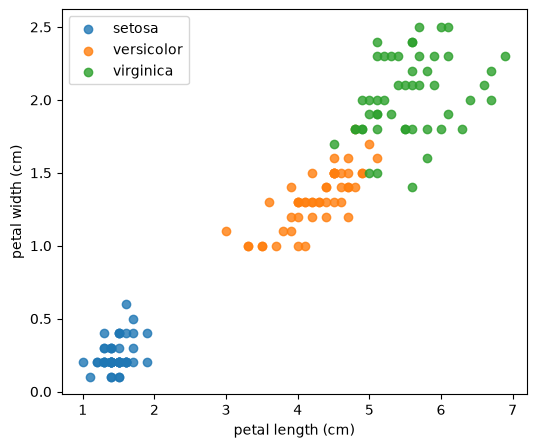

In [11]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(6,5))
for sp, group in df.groupby('species'):
    ax.scatter(group['petal length (cm)'], group['petal width (cm)'], label=sp, alpha=0.8)
ax.set_xlabel('petal length (cm)')
ax.set_ylabel('petal width (cm)')
ax.legend()
plt.savefig('../images/petal_scatter_by_species.png', dpi=120)
plt.show()

Setosa sits in a fully separate cluster of small petals; versicolor and virginica overlap slightly at the boundary. That overlap is the exact explanation for the model's one mistake below — the plot and the confusion matrix agree with each other.

## 10. Going further: confusion matrix, coefficients, and a second model *(not required by the tracker — added to connect theory to evidence)*

In [12]:
from sklearn.metrics import confusion_matrix
print(confusion_matrix(y_test, preds))  # rows = true label, columns = predicted

[[10  0  0]
 [ 0  9  1]
 [ 0  0 10]]


In [13]:
print(model.coef_)   # shape (3, 4): one row per class, one column per feature — magnitude shows how much each feature pushes toward that class

[[-5.29545300e-01  8.27264638e-01 -2.34737318e+00 -9.93393047e-01]
 [ 5.29709942e-01 -3.04722014e-01 -1.70953689e-01 -8.56067546e-01]
 [-1.64642293e-04 -5.22542624e-01  2.51832687e+00  1.84946059e+00]]


In [14]:
from sklearn.neighbors import KNeighborsClassifier
knn = KNeighborsClassifier(n_neighbors=5)
knn.fit(X_train, y_train)
print(accuracy_score(y_test, knn.predict(X_test)))

1.0


KNN scored higher here, but a single 30-row test set can't reliably crown a winner between two models this close — that comparison only becomes trustworthy with cross-validation, which is Day 3's job. Recorded here for context, not as a conclusion.

## 11. Summary — Day 1

**Built:**
- A clean, reproducible Iris DataFrame using the canonical convention (`feature_names` columns + integer `target` + string `species`).
- A stratified 80/20 train/test split (`random_state=42`) with verified class balance on both sides.
- A baseline `LogisticRegression` classifier, evaluated once on held-out data: **96.67% accuracy**, one versicolor → virginica miss.
- Supporting evidence: a petal length/width scatter plot, a confusion matrix, a look at the model's coefficients, and a KNN comparison flagged as not yet a reliable model-selection signal.

**Learned:**
- The three ML paradigms, grounded in automotive analogies — today's project is pure supervised learning.
- Train/test split discipline and why leakage inflates reported performance.
- Bias-variance tradeoff, read directly off this notebook's own result rather than just defined in the abstract.

**Carried forward to Day 2 and beyond:** this notebook's split parameters and baseline-first discipline are reused as-is. The single-split validation strategy here is intentionally provisional — cross-validation (Day 3) and a feature-scaling pipeline (Day 5) are the next upgrades, not added here on purpose.